In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score, classification_report, RocCurveDisplay
from sklearn.inspection import permutation_importance

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

df = pd.read_csv("../data/cleaned/playstore_features.csv")
print(df.shape)   # expect (9658, 22)

(9658, 22)


In [2]:
# Features a founder can control BEFORE launch
feature_cols_num = ["Size_MB", "Price", "Days_Since_Update"]
feature_cols_cat = ["Category", "Content Rating"]

# Explicitly excluded, and why:
excluded = {
    "Reviews": "outcome of success (ρ=0.97 with Installs), not a lever",
    "Rating": "only exists after launch and real usage",
    "Installs": "this IS the target, leaking it would be circular",
    "Genres": "near-duplicate of Category, adds noise not signal",
}
print("Excluded features:", excluded)

X = df[feature_cols_num + feature_cols_cat].copy()
y = df["Success"].copy()

print(X.shape, y.shape)
print(y.value_counts(normalize=True).round(3))

Excluded features: {'Reviews': 'outcome of success (ρ=0.97 with Installs), not a lever', 'Rating': 'only exists after launch and real usage', 'Installs': 'this IS the target, leaking it would be circular', 'Genres': 'near-duplicate of Category, adds noise not signal'}
(9658, 5) (9658,)
Success
0    0.648
1    0.352
Name: proportion, dtype: float64


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (7726, 5) Test: (1932, 5)


In [7]:
from sklearn.preprocessing import StandardScaler

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler())
    ]), feature_cols_num),
    ("cat", OneHotEncoder(handle_unknown="ignore"), feature_cols_cat),
])

In [5]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
dummy_acc = dummy.score(X_test, y_test)
print(f"Dummy baseline accuracy (always predict 'fail'): {dummy_acc:.3f}")

Dummy baseline accuracy (always predict 'fail'): 0.648


In [8]:
logreg = Pipeline([
    ("pre", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))
])
logreg.fit(X_train, y_train)

logreg_proba = logreg.predict_proba(X_test)[:, 1]
logreg_auc = roc_auc_score(y_test, logreg_proba)
print(f"Logistic Regression ROC-AUC: {logreg_auc:.3f}")
print(classification_report(y_test, logreg.predict(X_test)))

Logistic Regression ROC-AUC: 0.763
              precision    recall  f1-score   support

           0       0.82      0.68      0.74      1252
           1       0.55      0.72      0.62       680

    accuracy                           0.69      1932
   macro avg       0.68      0.70      0.68      1932
weighted avg       0.72      0.69      0.70      1932



In [9]:
rf = Pipeline([
    ("pre", preprocessor),
    ("clf", RandomForestClassifier(
        n_estimators=300, max_depth=10, min_samples_leaf=20,
        class_weight="balanced", random_state=42, n_jobs=-1
    ))
])
rf.fit(X_train, y_train)

rf_proba = rf.predict_proba(X_test)[:, 1]
rf_auc = roc_auc_score(y_test, rf_proba)
print(f"Random Forest ROC-AUC: {rf_auc:.3f}")
print(classification_report(y_test, rf.predict(X_test)))

Random Forest ROC-AUC: 0.828
              precision    recall  f1-score   support

           0       0.84      0.79      0.81      1252
           1       0.65      0.72      0.68       680

    accuracy                           0.76      1932
   macro avg       0.74      0.75      0.75      1932
weighted avg       0.77      0.76      0.76      1932



In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X, y, cv=cv, scoring="roc_auc")
print(f"5-fold CV ROC-AUC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

5-fold CV ROC-AUC: 0.819 ± 0.004


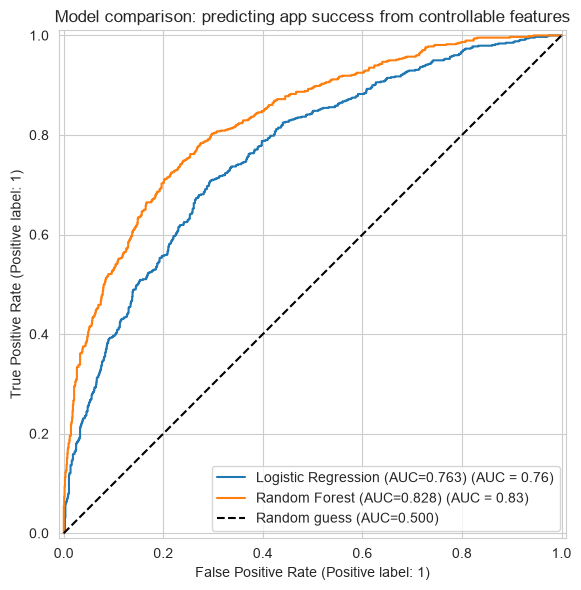

In [11]:
fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_predictions(y_test, logreg_proba, name=f"Logistic Regression (AUC={logreg_auc:.3f})", ax=ax)
RocCurveDisplay.from_predictions(y_test, rf_proba, name=f"Random Forest (AUC={rf_auc:.3f})", ax=ax)
ax.plot([0, 1], [0, 1], "k--", label="Random guess (AUC=0.500)")
ax.set_title("Model comparison: predicting app success from controllable features")
ax.legend()
plt.tight_layout()
plt.savefig("../images/07_roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

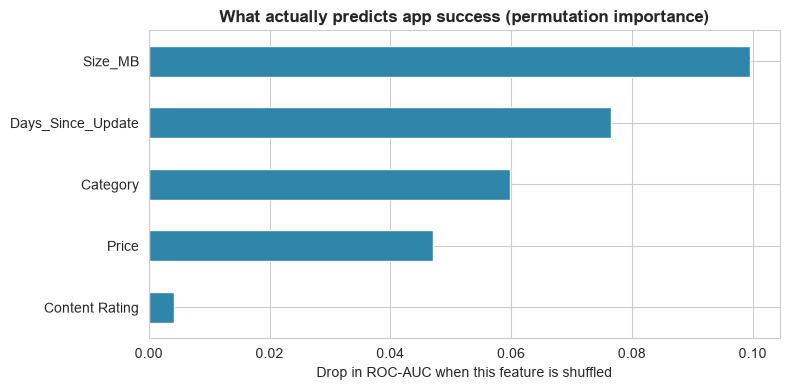

Size_MB              0.099551
Days_Since_Update    0.076541
Category             0.059748
Price                0.046997
Content Rating       0.004249
dtype: float64


In [12]:
result = permutation_importance(
    rf, X_test, y_test, n_repeats=15, scoring="roc_auc", random_state=42, n_jobs=-1
)

# Map back to original feature names (before one-hot encoding got applied inside the pipeline)
importances = pd.Series(result.importances_mean, index=X_test.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
importances.plot(kind="barh", ax=ax, color="#2E86AB")
ax.invert_yaxis()
ax.set_title("What actually predicts app success (permutation importance)", fontsize=12, fontweight="bold")
ax.set_xlabel("Drop in ROC-AUC when this feature is shuffled")
plt.tight_layout()
plt.savefig("../images/08_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print(importances)

## Model Limitations
This model explains a modest share of what drives success (ROC-AUC ≈ [X]) because it
deliberately excludes outcome-based features (Reviews, Rating) to avoid leakage. Real-world
success also depends on factors absent from this dataset: marketing spend, developer
reputation, ASO (app store optimization), and product quality. The model's value is in
ranking the *controllable* levers (category, price, size, update cadence) that a founder
can act on before launch, not in achieving maximum predictive accuracy.
## Model Results

| Model | ROC-AUC | Notes |
|---|---|---|
| Dummy baseline | 0.500 (accuracy 0.648) | Always predicts "fail" |
| Logistic Regression | 0.763 | Linear baseline |
| Random Forest | 0.828 | Main model |
| Random Forest (5-fold CV) | 0.819 ± 0.004 | Confirms stability across splits |

**Feature importance (permutation, drop in ROC-AUC when shuffled):**
1. Size_MB (0.100) — largest single driver
2. Days_Since_Update (0.077)
3. Category (0.060)
4. Price (0.047)
5. Content Rating (0.004) — negligible

**Cross-validation with Step 5:** the top 3 drivers (size, update recency, category) independently
confirm the statistical tests from Step 5, giving two separate methods agreeing on the same
conclusions. Price's importance here is smaller than its raw effect size in Step 5 suggested,
likely because pricing correlates with category (most successful categories are also
predominantly free), so the model attributes some of that shared signal to Category instead.

## Model Limitations
This model uses only pre-launch, controllable features (Size, Price, Category, Content Rating,
Update recency) and deliberately excludes Reviews and Rating, which are outcomes of success
rather than causes, to avoid leakage. An AUC of 0.828 with this restriction means these five
factors meaningfully predict outcomes, but real-world success also depends on marketing,
brand, ASO, and product quality, factors absent from this dataset. This model's value is in
ranking controllable levers, not maximizing raw predictive accuracy.

In [13]:
df_dict = {"logreg_auc": logreg_auc, "rf_auc": rf_auc, "cv_mean": cv_scores.mean(), "cv_std": cv_scores.std()}
print(df_dict)

{'logreg_auc': 0.762883504040594, 'rf_auc': 0.8278196062770156, 'cv_mean': np.float64(0.8187058409049202), 'cv_std': np.float64(0.004443514843096906)}
